<a href="https://colab.research.google.com/github/anishchapagain/AnishPython/blob/master/facedetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Demonstrate face detection using OpenCV's Haar Cascade classifier, including installation of `opencv-python`, downloading the classifier, loading an image, detecting faces, drawing bounding boxes, and displaying the result.

## Prepare Environment

### Subtask:
Install necessary libraries like `opencv-python` and download a pre-trained Haar Cascade classifier for face detection.


**Reasoning**:
To prepare the environment, I will first install the `opencv-python` library and then download the pre-trained Haar Cascade classifier for face detection from the specified URL.



In [1]:
import os

# Install opencv-python
!pip install opencv-python

# Download the Haar Cascade XML file
HAAR_CASCADE_URL = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
HAAR_CASCADE_FILENAME = "haarcascade_frontalface_default.xml"

if not os.path.exists(HAAR_CASCADE_FILENAME):
    !wget -q $HAAR_CASCADE_URL -O $HAAR_CASCADE_FILENAME
    print(f"Downloaded {HAAR_CASCADE_FILENAME}")
else:
    print(f"{HAAR_CASCADE_FILENAME} already exists.")

print("Environment setup complete.")

Downloaded haarcascade_frontalface_default.xml
Environment setup complete.


## Load Image and Classifier

### Subtask:
Load an image from a specified path and initialize the Haar Cascade classifier.


**Reasoning**:
I will import the `cv2` library, create a dummy image if `test_image.jpg` does not exist, load the image, and then initialize the Haar Cascade classifier using the previously downloaded XML file.



In [11]:
import cv2
import numpy as np

In [15]:
# Define image path
# IMAGE_PATH = 'test_image.jpg'
image_paths = [
'/content/59b43c93-4da4-4ba3-9ee7-da71000cc394_selfie_20251221_040214.jpg',
'/content/638c786c-864e-4f4c-8cea-4edfd2989392_selfie_20251223_090734.jpg',
'/content/7ecb56ee-7ec8-4ff7-bbd7-cd10effae8e2_selfie_20251222_094635.jpg',
'/content/c12cd378-3b99-4e8f-a02b-5826dcb5827e_selfie_20251221_040856.jpg',
                '/content/WhatsApp Image 2025-12-21 at 11.05.20.jpeg'
]

Using existing image: /content/59b43c93-4da4-4ba3-9ee7-da71000cc394_selfie_20251221_040214.jpg


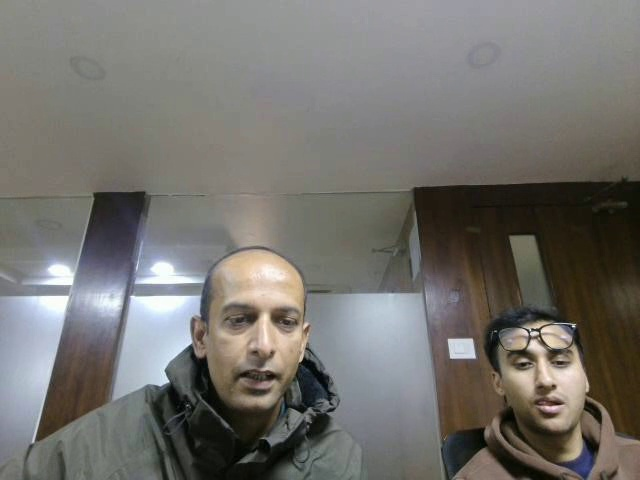

Image loaded successfully.
Haar Cascade classifier loaded successfully.
Found 3 face(s) in the image.
Displaying image with detected faces. Close the window to continue.


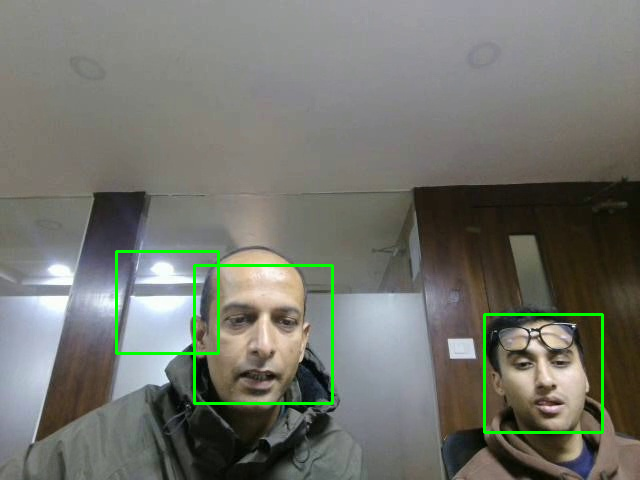

----------------------------------------
Using existing image: /content/638c786c-864e-4f4c-8cea-4edfd2989392_selfie_20251223_090734.jpg


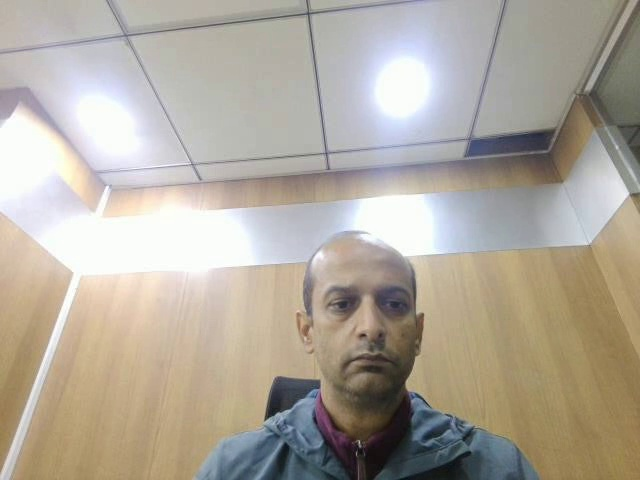

Image loaded successfully.
Haar Cascade classifier loaded successfully.
Found 1 face(s) in the image.
Displaying image with detected faces. Close the window to continue.


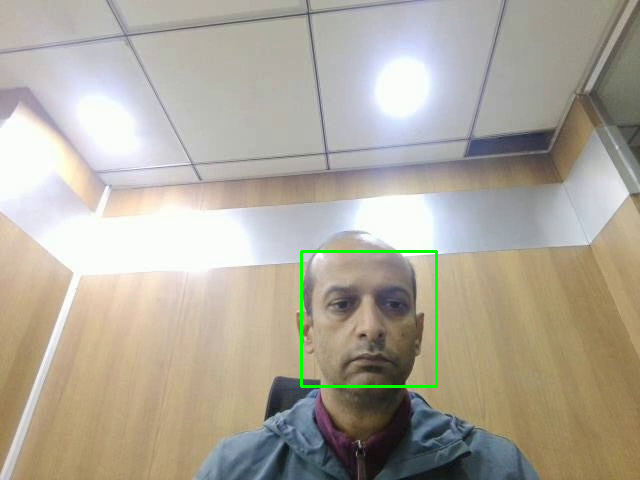

----------------------------------------
Using existing image: /content/7ecb56ee-7ec8-4ff7-bbd7-cd10effae8e2_selfie_20251222_094635.jpg


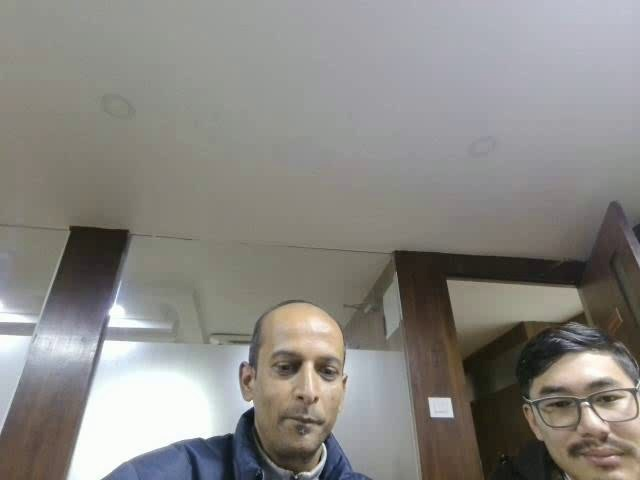

Image loaded successfully.
Haar Cascade classifier loaded successfully.
Found 2 face(s) in the image.
Displaying image with detected faces. Close the window to continue.


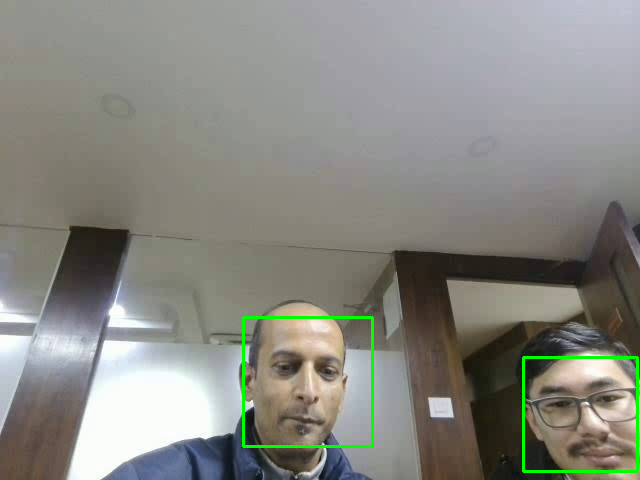

----------------------------------------
Using existing image: /content/c12cd378-3b99-4e8f-a02b-5826dcb5827e_selfie_20251221_040856.jpg


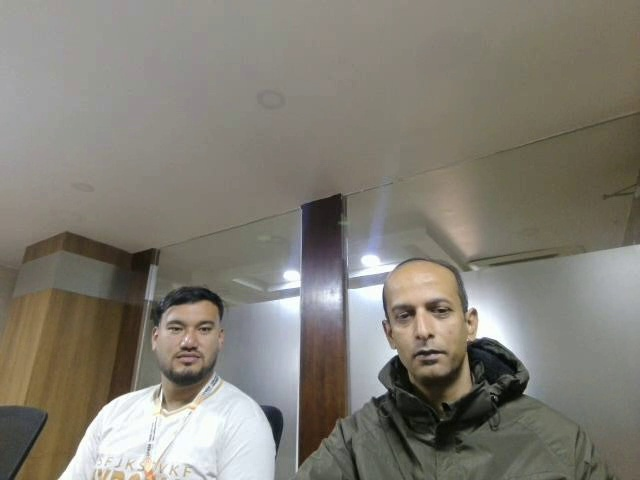

Image loaded successfully.
Haar Cascade classifier loaded successfully.
Found 2 face(s) in the image.
Displaying image with detected faces. Close the window to continue.


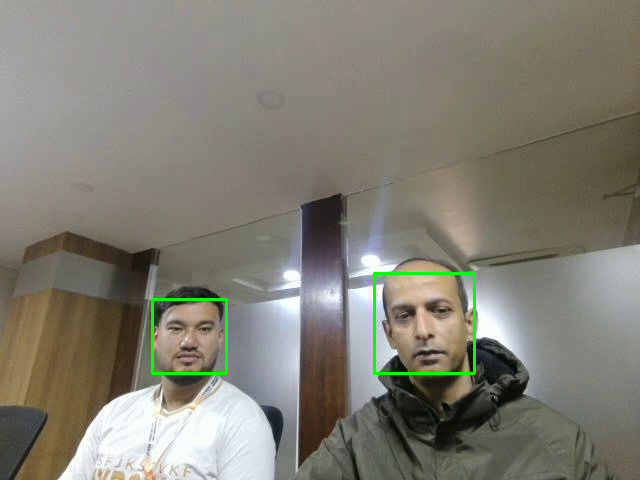

----------------------------------------


In [20]:
from google.colab.patches import cv2_imshow

for image_path in image_paths:
  IMAGE_PATH = image_path
  # Create a dummy image if it doesn't exist for demonstration purposes
  if not os.path.exists(IMAGE_PATH):
      dummy_image = np.zeros((300, 400, 3), dtype=np.uint8)
      cv2.putText(dummy_image, "Upload 'test_image.jpg' or use this dummy", (10, 150), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
      cv2.imwrite(IMAGE_PATH, dummy_image)
      print(f"Created a dummy image: {IMAGE_PATH}. Please upload your own image with this name for actual face detection.")
  else:
      print(f"Using existing image: {IMAGE_PATH}")

  # Load the image
  image = cv2.imread(IMAGE_PATH)
  cv2_imshow(image)


  # Check if image loading was successful
  if image is None:
      print(f"Error: Could not load image from {IMAGE_PATH}. Please ensure the file exists and is a valid image.")
      continue # Skip to the next iteration if image loading failed
  else:
      print("Image loaded successfully.")

  # Initialize the Haar Cascade classifier
  face_cascade = cv2.CascadeClassifier(HAAR_CASCADE_FILENAME)

  # Check if classifier loaded successfully
  if face_cascade.empty():
      print(f"Error: Could not load Haar Cascade classifier from {HAAR_CASCADE_FILENAME}.")
      continue # Skip if classifier not loaded
  else:
      print("Haar Cascade classifier loaded successfully.")

  # Convert the image to grayscale
  gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  faces = face_cascade.detectMultiScale(gray_image, scaleFactor=1.1, minNeighbors=4)
  print(f"Found {len(faces)} face(s) in the image.")
  if len(faces) > 0:
    for (x, y, w, h) in faces:
        cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)
    print("Displaying image with detected faces. Close the window to continue.")
    cv2_imshow(image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
  else:
      print("No faces detected to draw bounding boxes. Displaying original image.")
  print("--"*20)